# **Creating Movie Lists Based On Personality**

Chak Wong and Jaclyn Etzel

# **Introduction**
### **How do you assess personality?**
There are many ways to assess personality, but there are five personality metrics that can create a fairly well-rounded image of someone’s personality. These are openness, agreeableness, emotional stability, conscientiousness, and extraversion. Openness is the tendency to prefer new experiences. Agreeableness is the tendency to be compassionate and cooperative rather than suspicious and antagonistic towards others. Emotional stability is the tendency to have psychological stress. Conscientiousness is the tendency to be organized and dependable, and show self-discipline. Extraversion is the tendency to be outgoing.

### **How do you pair movie lists with the right personality?**
The movie lists are created with a few quality metrics in mind - serendipity, popularity, diversity, or all three! Each movie list then is given a condition for its assigned quality metric - high, default, medium, or low. For example, there are lists with high diversity, medium diversity, and low diversity. Our job is to figure out which personalities go with which type of movie!

### **How is Data Science useful in curating personalized movie lists?**
After taking data from users who have received their curated movie lists based on their personality and rated whether they enjoyed them, we will be able to analyze this data and search for patterns as to which type of movie lists go with each personality. In the end, we will be able to give users a movie list they are likely to love and rate accordingly. We will be using the data science life cycle to find out which personalities prefer which types of movies in this tutorial. The data science life cycle consists of the following steps:  
*   Data Collection
*   Data processing 
*   Exploratory analysis and data visualization
*   Analysis, hypothesis testing, and machine learning
*   Insight and policy decision


### **Technology Introduction**

Before we begin, here are some resources for understanding the languages, libraries, and technologies we will be using in this tutorial. Feel free to click on the links to learn more about that resource! 


*   [Python](https://www.python.org/)
*   [pandas](https://pandas.pydata.org/)
*   [seaborn](https://seaborn.pydata.org/)
*   [numpy](https://numpy.org/)
*   [scikit](https://scikit-learn.org/stable/)


# **Data Collection**
The source of our data is from kaggle, which is an online public service that users can upload and share datasets for free. The direct link for our source can be found [here](https://www.kaggle.com/arslanali4343/top-personality-dataset).

### **Data Size**
This dataset contains information for over 1820 users. This dataset has 1834 rows and 34 columns.

### **Data Content**
The dataset contains the users and their personality metrics, assigned movie quality and condition for their list, the movie list assigned to them, and whether they enjoyed watching the movies on the list. 

Let’s jump right in! To start, download the data set from the link above. Then you’ll want to read it into a pandas dataframe. Then we’ll print a list of all the attributes in the dataset. 


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [ ]:
personality_data = pd.read_csv('/content/2018-personality-data.csv')
personality_data.columns

Index(['userid', ' openness', ' agreeableness', ' emotional_stability',
       ' conscientiousness', ' extraversion', ' assigned metric',
       ' assigned condition', ' movie_1', ' predicted_rating_1', ' movie_2',
       ' predicted_rating_2', ' movie_3', ' predicted_rating_3', ' movie_4',
       ' predicted_rating_4', ' movie_5', ' predicted_rating_5', ' movie_6',
       ' predicted_rating_6', ' movie_7', ' predicted_rating_7', ' movie_8',
       ' predicted_rating_8', ' movie_9', ' predicted_rating_9', ' movie_10',
       ' predicted_rating_10', ' movie_11', ' predicted_rating_11',
       ' movie_12', ' predicted_rating_12', ' is_personalized',
       ' enjoy_watching '],
      dtype='object')

# **Data Processing**

Now that we have collected the data, let's get rid of what we're not using! 

In [ ]:
personality_data = personality_data.drop(['userid',
                  ' movie_1', ' predicted_rating_1',
                  ' movie_2', ' predicted_rating_2',
                  ' movie_3', ' predicted_rating_3',
                  ' movie_4', ' predicted_rating_4',
                  ' movie_5', ' predicted_rating_5',
                  ' movie_6', ' predicted_rating_6',
                  ' movie_7', ' predicted_rating_7',
                  ' movie_8', ' predicted_rating_8',
                  ' movie_9', ' predicted_rating_9',
                  ' movie_10', ' predicted_rating_10',
                  ' movie_11', ' predicted_rating_11',
                  ' movie_12', ' predicted_rating_12',
                  ], axis=1)

In [ ]:
personality_data

,openness,agreeableness,emotional_stability,conscientiousness,extraversion,assigned metric,assigned condition,is_personalized,enjoy_watching
0,5.0,2.0,3.0,2.5,6.5,serendipity,high,4,4
1,7.0,4.0,6.0,5.5,4.0,all,default,2,3
2,4.0,3.0,4.5,2.0,2.5,serendipity,medium,2,2
3,5.5,5.5,4.0,4.5,4.0,popularity,medium,3,3
4,5.5,5.5,3.5,4.5,2.5,popularity,medium,2,3
...,...,...,...,...,...,...,...,...,...
1829,5.5,3.5,2.5,4.0,5.5,popularity,low,3,3
1830,4.0,3.5,4.5,4.0,2.5,serendipity,high,3,4
1831,6.0,3.0,5.5,3.5,6.0,serendipity,low,3,4
1832,5.0,3.5,1.5,3.5,2.5,serendipity,medium,4,4


Now we're just going to do some formatting and get rid of extra spaces in the column names! 

In [ ]:
columns_names = {' openness': 'openness', ' agreeableness': 'agreeableness', ' emotional_stability': 'emotional_stability',
               ' conscientiousness': 'conscientiousness', ' extraversion': 'extraversion', ' assigned metric': 'assigned metric',
               ' assigned condition': 'assigned condition', ' is_personalized': 'is_personalized', ' enjoy_watching ': 'enjoy_watching'}
personality_data = personality_data.rename(columns = columns_names)

In [ ]:
personality_data

,openness,agreeableness,emotional_stability,conscientiousness,extraversion,assigned metric,assigned condition,is_personalized,enjoy_watching
0,5.0,2.0,3.0,2.5,6.5,serendipity,high,4,4
1,7.0,4.0,6.0,5.5,4.0,all,default,2,3
2,4.0,3.0,4.5,2.0,2.5,serendipity,medium,2,2
3,5.5,5.5,4.0,4.5,4.0,popularity,medium,3,3
4,5.5,5.5,3.5,4.5,2.5,popularity,medium,2,3
...,...,...,...,...,...,...,...,...,...
1829,5.5,3.5,2.5,4.0,5.5,popularity,low,3,3
1830,4.0,3.5,4.5,4.0,2.5,serendipity,high,3,4
1831,6.0,3.0,5.5,3.5,6.0,serendipity,low,3,4
1832,5.0,3.5,1.5,3.5,2.5,serendipity,medium,4,4


In [ ]:
personality_data['assigned metric'] = personality_data['assigned metric'].replace([' serendipity'], 'serendipity')
personality_data['assigned metric'] = personality_data['assigned metric'].replace([' popularity'], 'popularity')
personality_data['assigned metric'] = personality_data['assigned metric'].replace([' diversity'], 'diversity')
personality_data['assigned condition'] = personality_data['assigned condition'].replace([' low'], 'low')
personality_data['assigned condition'] = personality_data['assigned condition'].replace([' medium'], 'medium')
personality_data['assigned condition'] = personality_data['assigned condition'].replace([' high'], 'high')

# **Exploratory Analysis and Data Visualization**
Now that we have our data here and ready to analyze, let's hop right in! Let's look at people's level of openness and their level of enjoyment in their movie lists! 

/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:3704: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


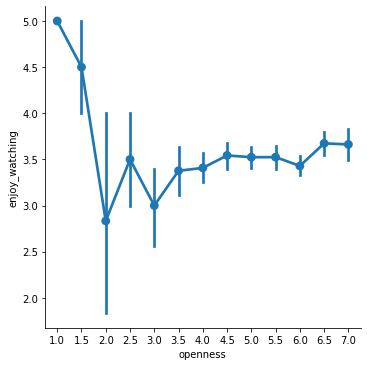

In [ ]:
sns.factorplot( x = 'openness', y = 'enjoy_watching', data = personality_data)


On a scale of 1 to 7 on openness, the higher the number, the more likely that an individual has a tendency to prefer new experience Within this plot, we can see that there’s a fairly upward trend after going past the first two levels of openness as they claim that the openness increases with the enjoyment level. However, the lower end points of the plot suggested otherwise as the lowest level of openness, 1.0, tends to have the highest amount of enjoyment level.



#####Now let’s look at the user's level of agreeableness and their level of enjoyment in their movie lists!

/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:3704: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


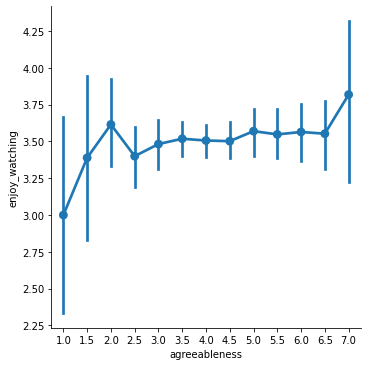

In [ ]:
sns.factorplot( x = 'agreeableness', y = 'enjoy_watching', data = personality_data)

On a scale of 1 to 7 on agreeableness, the higher the number, the more likely that an individual has a tendency to be compassionate and cooperative with others. Within this plot, we can see that there’s a fairly flat trend claiming that the agreeableness does not really affect the enjoyment level. However, the end points of the plot claims that an extreme level of agreeableness can have an influence as the lower end point agreeableness tends to have a lower enjoyment level than the average, and this is the same with the higher end point of agreeableness as it tends to have a higher level of enjoyment compared to the average. 

Now let’s look at user’s level of emotional stability and their level of enjoyment in the movie lists! 


/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:3704: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


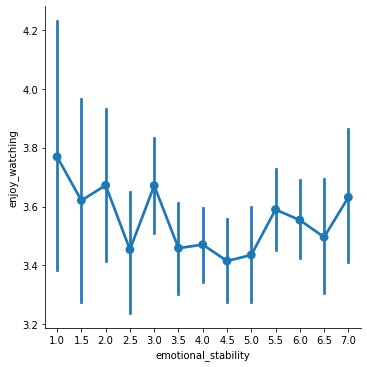

In [ ]:
sns.factorplot( x = 'emotional_stability', y = 'enjoy_watching', data = personality_data)

On a scale of 1 to 7 on emotional stability, the higher the number, the more likely that an individual has a tendency to NOT have psychological stress. Within this plot, we can see that the points fluctuate up and down fairly often, but there is a general trend of a slight downward curve. Individuals within the average range of emotional stability (3.0 to 5.0) tend to have the lowest enjoyment level of all levels of emotional stability. Individuals with the most psychological stress tend to find the most enjoyment within movies as emotional stability level of 1.0 scored the highest on the enjoyment level.

Now let’s look at user’s level of conscientiousness and their level of enjoyment in the movie lists! 


/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:3704: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


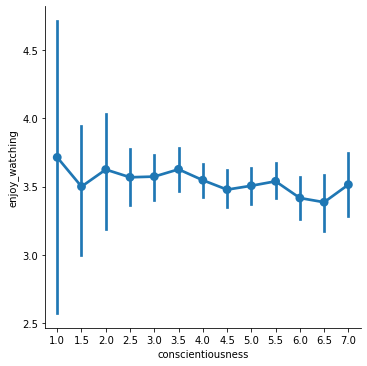

In [ ]:
sns.factorplot( x = 'conscientiousness', y = 'enjoy_watching', data = personality_data)

On a scale of 1 to 7 on conscientiousness, the higher the number, the more likely that an individual has a tendency to be organized and dependable, and show self-discipline. Within this plot, we can see that there’s a fairly flat trend claiming that the conscientiousness does not really affect the enjoyment level. However, there is a very slight downward trend as we move up on the conscientiousness scale. 

Now let’s look at user’s level of extraversion and their level of enjoyment in the movie lists! 


/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:3704: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


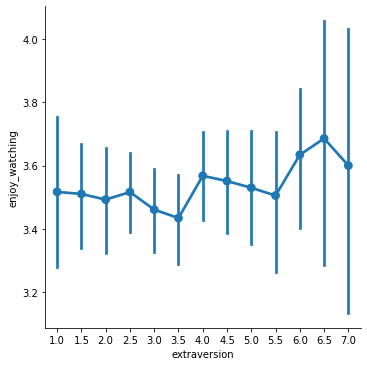

In [ ]:
sns.factorplot( x = 'extraversion', y = 'enjoy_watching', data = personality_data)

On a scale of 1 to 7 on extraversion, the higher the number, the more likely that an individual has a tendency to be outgoing. Within this plot, we can see that there’s a fairly upward trend claiming that the extraversion increases with the enjoyment level. The lowest enjoyment level within the extraversion scale would lie on the average as the 3.5 level of extraversion have the lowest enjoyment level.

Another attribute that could affect a user’s enjoyment of their movie list is the assigned quality metric and condition of their movie lists. Let’s look at each of the personality traits and user’s assigned quality metrics and conditions of their movie lists and see if we notice patterns for certain personality traits! First we’ll look at openness. 


In [ ]:
diversity_high = personality_data[(personality_data['assigned metric'] == 'diversity')
                                   & (personality_data[ 'assigned condition'] == 'high')]

diversity_low = personality_data[(personality_data['assigned metric'] == 'diversity')
                                  & (personality_data[ 'assigned condition'] == 'low')]

popularity_high = personality_data[(personality_data['assigned metric'] == 'popularity')
                                    & (personality_data[ 'assigned condition'] == 'high')]

popularity_low = personality_data[(personality_data['assigned metric'] == 'popularity')
                                   & (personality_data[ 'assigned condition'] == 'low')]

serendipity_high = personality_data[(personality_data['assigned metric'] == 'serendipity')
                                     & (personality_data[ 'assigned condition'] == 'high')]

serendipity_low= personality_data[(personality_data['assigned metric'] == 'serendipity')
                                   & (personality_data[ 'assigned condition'] == 'low')]

all = personality_data[(personality_data['assigned metric'] == 'all')
                                   & (personality_data[ 'assigned condition'] == 'default')]                  

Text(0.5, 1.0, 'Openness - Serendipity')

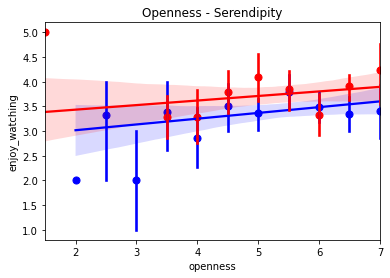

In [ ]:
sns.regplot(x = 'openness' , y = 'enjoy_watching', data = serendipity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'openness' , y = 'enjoy_watching', data = serendipity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Openness - Serendipity')

Text(0.5, 1.0, 'Openness - Popularity')

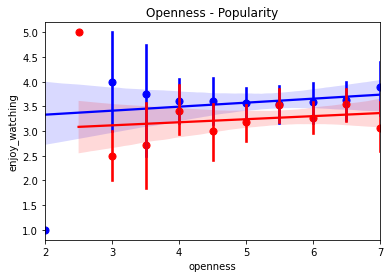

In [ ]:
sns.regplot(x = 'openness' , y = 'enjoy_watching', data = popularity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'openness' , y = 'enjoy_watching', data = popularity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Openness - Popularity')

Text(0.5, 1.0, 'Openness - Diversity')

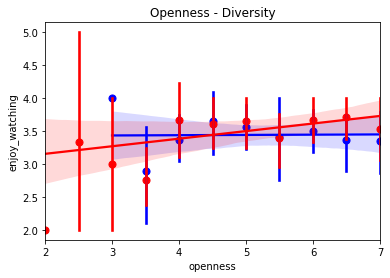

In [ ]:
sns.regplot(x = 'openness' , y = 'enjoy_watching', data = diversity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'openness' , y = 'enjoy_watching', data = diversity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Openness - Diversity')

Throughout all levels of openness, the first plot demonstrated that a lower level of serendipity would achieve a higher level of enjoyment. However, the second plot demonstrated that a higher level of popularity would achieve a higher level of enjoyment. The third plot demonstrated that diversity does not have much impact in terms of openness and enjoyment level as the red and blue tends to be right on each other, but the red line, which is low diversity, tends to be curving upwards whereas the blue line, which is high diversity, is curing downwards.

Now we’ll look at agreeableness

Text(0.5, 1.0, 'Agreeableness - Serendipity')

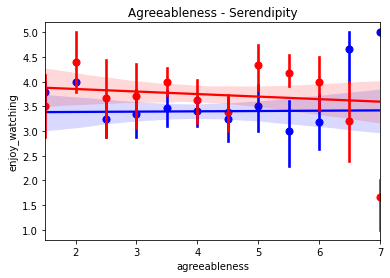

In [ ]:
sns.regplot(x = 'agreeableness' , y = 'enjoy_watching', data = serendipity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'agreeableness' , y = 'enjoy_watching', data = serendipity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Agreeableness - Serendipity')

Text(0.5, 1.0, 'Agreeableness - Popularity')

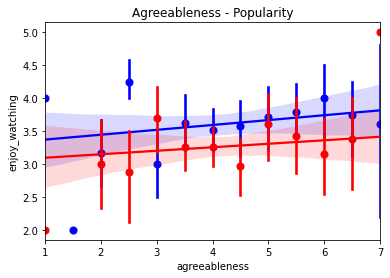

In [ ]:
sns.regplot(x = 'agreeableness' , y = 'enjoy_watching', data = popularity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'agreeableness' , y = 'enjoy_watching', data = popularity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Agreeableness - Popularity')

Text(0.5, 1.0, 'Agreeableness - Diversity')

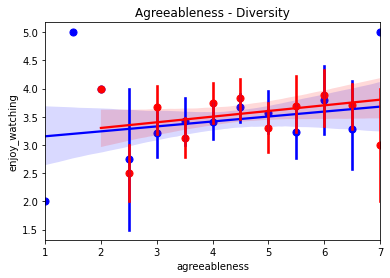

In [ ]:
sns.regplot(x = 'agreeableness' , y = 'enjoy_watching', data = diversity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'agreeableness' , y = 'enjoy_watching', data = diversity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Agreeableness - Diversity')

Throughout all levels of agreeableness, the first plot demonstrated that serendipity and agreeableness does not have much of an impact on the enjoyment level as the trend tends to be flat for both red and blue, with the exception of the fact that red is at a higher enjoyment level even though it is a slight downward trend. In terms of popularity, both blue and red are upward trends, however, the higher popularity yields a higher enjoyment level. In terms of diversity, both high and low diversity have the same trend as they are both trending upwards, but little diversity has a higher enjoyment level just slightly.


Now we’ll look at emotional stability 

Text(0.5, 1.0, 'Emotional Stability - Serendipity')

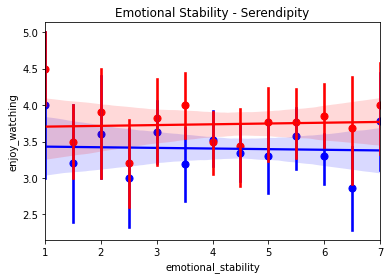

In [ ]:
sns.regplot(x = 'emotional_stability' , y = 'enjoy_watching', data = serendipity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'emotional_stability' , y = 'enjoy_watching', data = serendipity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Emotional Stability - Serendipity')

Text(0.5, 1.0, 'Emotional Stability - Popularity')

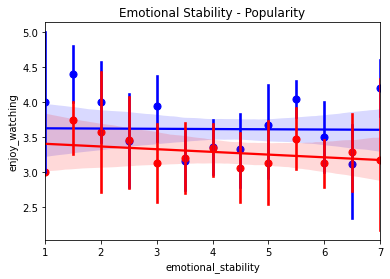

In [ ]:
sns.regplot(x = 'emotional_stability' , y = 'enjoy_watching', data = popularity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'emotional_stability' , y = 'enjoy_watching', data = popularity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Emotional Stability - Popularity')

Text(0.5, 1.0, 'Emotional Stability - Diversity')

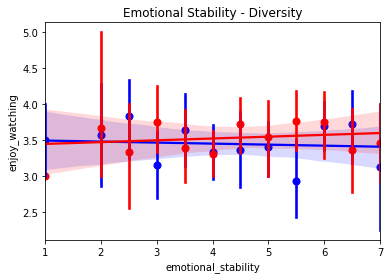

In [ ]:
sns.regplot(x = 'emotional_stability' , y = 'enjoy_watching', data = diversity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'emotional_stability' , y = 'enjoy_watching', data = diversity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Emotional Stability - Diversity')

In terms of emotional stability within serendipity, both red and blue lines are fairly flat, but the red line that indicates lower serendipity has a higher enjoyment level by average of 0.5. In terms of popularity, the higher popularity yields more enjoyment. Blue lines in this case are fairly flat while red is trending downwards. In terms of diversity, red and blue lights are almost alike as they are both flat and average the same, however, red tends to trend upwards while blue tends to trend downwards after reaching the average emotional stability, 4.0.

Now we'll look at conscientiousness

Text(0.5, 1.0, 'Conscientiousness - Serendipity')

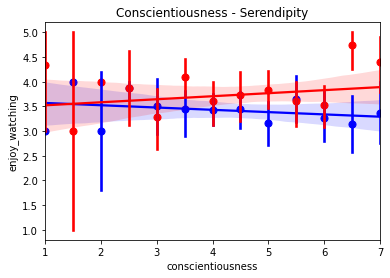

In [ ]:
sns.regplot(x = 'conscientiousness' , y = 'enjoy_watching', data = serendipity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'conscientiousness' , y = 'enjoy_watching', data = serendipity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Conscientiousness - Serendipity')

Text(0.5, 1.0, 'Conscientiousness - Popularity')

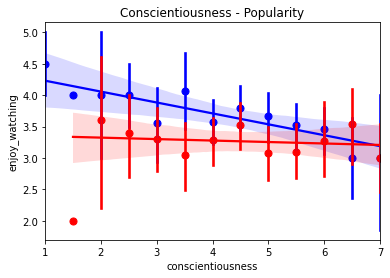

In [ ]:
sns.regplot(x = 'conscientiousness' , y = 'enjoy_watching', data = popularity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'conscientiousness' , y = 'enjoy_watching', data = popularity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Conscientiousness - Popularity')

Text(0.5, 1.0, 'Conscientiousness - Diversity')

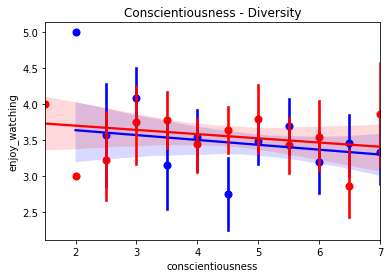

In [ ]:
sns.regplot(x = 'conscientiousness' , y = 'enjoy_watching', data = diversity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'conscientiousness' , y = 'enjoy_watching', data = diversity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Conscientiousness - Diversity')

In serendipity, red trends upwards while blue trends downwards, which means that as conscientiousness goes up, the lower serendipity would yield a higher enjoyment level. In terms of popularity, with low conscientiousness, a higher popularity would yield much enjoyment. However, as conscientiousness increases, the higher popularity would heavily trend downwards and meet with the lower popularity at the upper end of the conscientiousness scale. In terms of diversity, both red and blue are trending downwards. However, red is slightly above the blue line, which means that a lower diversity would yield a slightly more enjoyment level.

Now we'll look at extraversion

Text(0.5, 1.0, 'Extraversion - Serendipity')

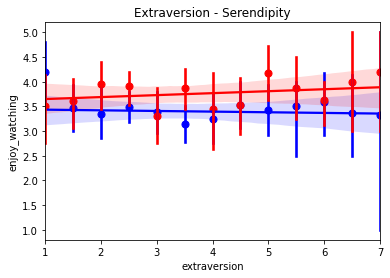

In [ ]:
sns.regplot(x = 'extraversion' , y = 'enjoy_watching', data = serendipity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'extraversion' , y = 'enjoy_watching', data = serendipity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Extraversion - Serendipity')

Text(0.5, 1.0, 'Extraversion - Popularity')

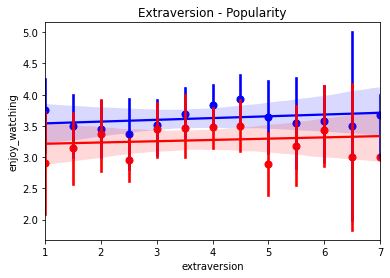

In [ ]:
sns.regplot(x = 'extraversion' , y = 'enjoy_watching', data = popularity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'extraversion' , y = 'enjoy_watching', data = popularity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Extraversion - Popularity')

Text(0.5, 1.0, 'Extraversion - Diversity')

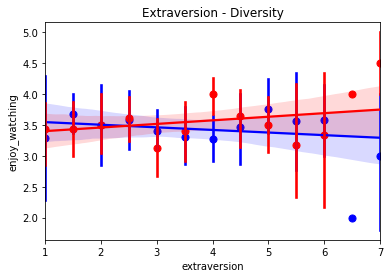

In [ ]:
sns.regplot(x = 'extraversion' , y = 'enjoy_watching', data =diversity_high, color = 'b', x_estimator = np.mean )
sns.regplot(x = 'extraversion' , y = 'enjoy_watching', data = diversity_low, color = 'r' ,x_estimator = np.mean )

plt.title('Extraversion - Diversity')

When it comes to serendipity on extraversion, red trends upwards, while blue trends downwards, which means that a lower serendipity would yield a higher enjoyment level in terms of extraversion. In terms of popularity, both blue and red have the same trending pattern, however, blue has a higher enjoyment level regardless. This means that a higher popularity would lead to more enjoyment level in terms of extraversion. In terms of diversity, red trends upwards, while blue trends downwards. This means that lower diversity would yield higher enjoyment level going past the average extraversion levels, 3.0. 


# **Model Creation and Analysis**

Now we need to do a one-hot encoding of our data 


In [ ]:
{column: list(personality_data[column].unique()) for column in personality_data.columns if personality_data.dtypes[column] == 'object'}

{'assigned condition': ['high', ' default', 'medium', 'low'],
 'assigned metric': ['serendipity', ' all', 'popularity', 'diversity']}

In [ ]:
personality_data['assigned condition'].mode()

0    high
dtype: object

In [ ]:
condition_ordering = ['low', 'medium', ' default', 'high']
def ordinal_encode(df, column, ordering):
    df = df.copy()
    df[column] = df[column].apply(lambda x: ordering.index(x))
    return df

def onehot_encode(df, column, prefix):
    df = df.copy()
    dummies = pd.get_dummies(df[column], prefix=prefix)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(column, axis=1)
    return df
personality_data = ordinal_encode(personality_data, 'assigned condition', condition_ordering)
personality_data = onehot_encode(personality_data, 'assigned metric', 'm')
personality_data

,openness,agreeableness,emotional_stability,conscientiousness,extraversion,assigned condition,is_personalized,enjoy_watching,m_ all,m_diversity,m_popularity,m_serendipity
0,5.0,2.0,3.0,2.5,6.5,3,4,4,0,0,0,1
1,7.0,4.0,6.0,5.5,4.0,2,2,3,1,0,0,0
2,4.0,3.0,4.5,2.0,2.5,1,2,2,0,0,0,1
3,5.5,5.5,4.0,4.5,4.0,1,3,3,0,0,1,0
4,5.5,5.5,3.5,4.5,2.5,1,2,3,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1829,5.5,3.5,2.5,4.0,5.5,0,3,3,0,0,1,0
1830,4.0,3.5,4.5,4.0,2.5,3,3,4,0,0,0,1
1831,6.0,3.0,5.5,3.5,6.0,0,3,4,0,0,0,1
1832,5.0,3.5,1.5,3.5,2.5,1,4,4,0,0,0,1


Now we have to split the data and scale it 

In [ ]:
y = personality_data['enjoy_watching']
X = personality_data.drop('enjoy_watching', axis=1)

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

Now comes the time to pick which model we’re going to use. We’re going to try 3 here - logistic regression, support vector machine, and a neural network. 

In [ ]:
log_model = LogisticRegression()
svm_model = SVC(C=1.0)
ann_model = MLPClassifier(hidden_layer_sizes=(16))

log_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
ann_model.fit(X_train, y_train)

log_acc = log_model.score(X_test, y_test)
svm_acc = svm_model.score(X_test, y_test)
ann_acc = ann_model.score(X_test, y_test)

/usr/local/lib/python3.6/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)


In [ ]:
print("Logistic Regression:", log_acc)
print("Support Vector Machine:", svm_acc)
print("Neural Network:", ann_acc)

Logistic Regression: 0.5027223230490018
Support Vector Machine: 0.484573502722323
Neural Network: 0.5027223230490018


In [ ]:
fig = px.bar(
    x=['Logistic Regression', 'Support Vector Machine', 'Neural Network'],
    y=[log_acc, svm_acc, ann_acc],
    color=['Logistic Regression', 'Support Vector Machine', 'Neural Network'],
    labels={'x': "Model", 'y': "Accuracy"},
    title="Model Accuracy"
)

fig.show()

# **Conclusion**

After analyzing and visualizing the data, we were able to come up with two models of 50% accuracy. 

There is much more room for improvement, though there are many many more to try! With our examples in this tutorial, you can go and try more and compare them! 

To read a fun article about similar research done to our dataset with different personality metrics click the link below:

https://www.lifehack.org/417256/what-your-movie-preferences-say-about-you-according-to-researchers

More research on movie preference based on personality: 

https://shareok.org/bitstream/handle/11244/52350/oksd_romans_HT_2015.pdf?sequence=1&isAllowed=y